In [72]:
import pandas as pd
import seaborn as srn
import statistics as sts

In [73]:
#Importando dados
dataset = pd.read_csv("Churn.csv", sep=";")
#Visualizar dados
dataset.head()

,X0,X1,X2,X3,X4,X4.1,X6,X7,X8,X9,X10,X11
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


In [74]:
#tamanho
dataset.shape

(999, 12)

In [75]:
dataset.columns = ["Id", "Score", "Estado", "Genero", "Idade", "Patrimonio", "Saldo", "Produtos",
                    "TemCartCredito", "Ativo","Salario", "Saiu"]

dataset.head()

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


In [76]:
#Explorar dados categóricos
dataset.groupby(['Estado']).size()

Estado
PR    257
RP      1
RS    478
SC    258
SP      4
TD      1
dtype: int64

In [77]:
#Substituir os valores incorretos
dataset.loc[dataset['Estado'] == 'RP', 'Estado'] = 'PR'
dataset.loc[dataset['Estado'].isin(['SP', 'TD']), 'Estado'] = 'RS'

dataset.groupby(['Estado']).size()

Estado
PR    258
RS    483
SC    258
dtype: int64

In [78]:
#Genero
dataset.groupby(['Genero']).size()

Genero
F              2
Fem            1
Feminino     461
M              6
Masculino    521
dtype: int64

In [79]:
#Substituir por valores corretos, e o RS pelo moda
dataset.loc[dataset['Genero'].isin(['F', 'Fem']), 'Genero'] = 'Feminino'
dataset.loc[dataset['Genero'].isin(['M','RS']), 'Genero'] = 'Masculino'

dataset.groupby(['Genero']).size()

Genero
Feminino     464
Masculino    527
dtype: int64

<Axes: ylabel='Score'>

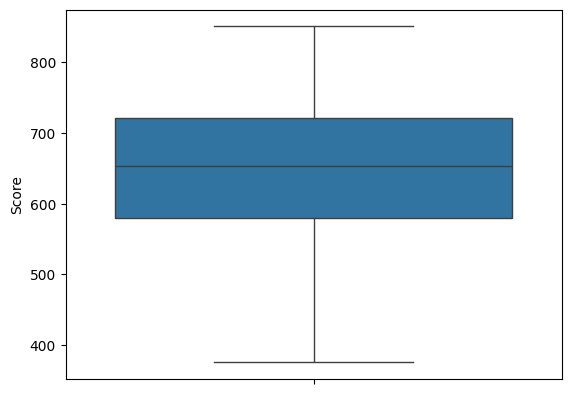

In [80]:
# Explorar colunas numericas (SCORE)
agrupado_score = dataset['Score'].describe() #Criando resumo estatístico da coluna Score

srn.boxplot(dataset['Score'])

count    999.000000
mean      38.902903
std       11.401912
min      -20.000000
25%       32.000000
50%       37.000000
75%       44.000000
max      140.000000
Name: Idade, dtype: float64

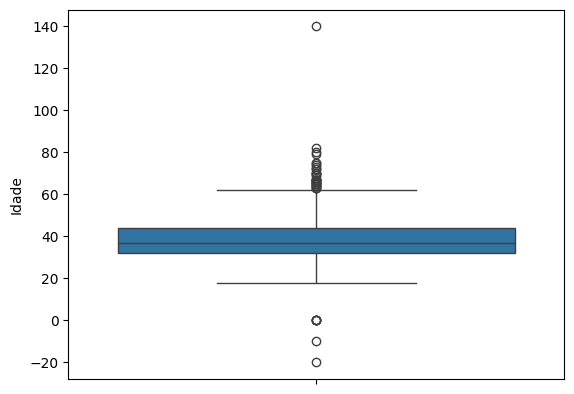

In [81]:
#Idade
agrupado_idade = dataset['Idade'].describe() #Criando resumo estatístico da coluna Score

srn.boxplot(dataset['Idade']) #Checando o desvio padrão por meio do gráfico boxplot

agrupado_idade

In [82]:
medianaIdade = sts.median(dataset['Idade']) #Definindo a mediana da Idade

dataset.loc[(dataset['Idade'] > 18) | (dataset['Idade'] < 120), 'Idade'] = medianaIdade #Substituindo os valores fora da do espaço pela mediana

dataset['Idade'].describe()

count    999.0
mean      37.0
std        0.0
min       37.0
25%       37.0
50%       37.0
75%       37.0
max       37.0
Name: Idade, dtype: float64

In [83]:
#Id
dataset[dataset.duplicated(['Id'], keep=False)] #Veriricando se há valores duplicados

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
80,81,665,RS,Feminino,37,1,9664554,2,0,0,17141366.0,0
81,81,665,RS,Feminino,37,1,9664554,2,0,0,17141366.0,0


In [84]:
dataset.drop_duplicates(subset='Id', keep='first', inplace=True) #Removendo duplicatas
dataset[dataset.duplicated(['Id'], keep=False)]

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu


In [90]:
#Salario $$
desvPadSalario = sts.stdev(dataset['Salario'].dropna()) #Definindo desvio padrão
dataset.loc[dataset['Salario'] >=  2 * desvPadSalario] #Checando se algum valor é maior que 2desvPad

,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
0,1,619,RS,Feminino,37,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,37,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,37,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,37,1,0,2,0,0,9382663.0,0
10,11,528,RS,Masculino,37,6,10201672,2,0,0,8018112.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
986,988,566,RS,Masculino,37,1,14212091,1,1,0,7961637.0,0
987,989,569,SC,Masculino,37,0,15183926,1,1,0,10229981.0,1
988,990,659,SC,Feminino,37,7,14962088,2,1,1,10453351.0,0
993,995,661,SC,Feminino,37,7,9535749,1,0,0,10229715.0,0


In [ ]:
medianaSalario = sts.median(dataset['Salario']) #Definindo a mediana

dataset.loc[(dataset['Salario'] >= 2 * desvPadSalario), 'Salario'] = medianaSalario #Substituindo valores maiores ou igauis a 2desPad pela mediana


dataset.loc[dataset['Salario'] >=  2 * desvPadSalario ] #Checando se algum valor é maior que 2desvPad


,Id,Score,Estado,Genero,Idade,Patrimonio,Saldo,Produtos,TemCartCredito,Ativo,Salario,Saiu
